In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [36]:
from scipy import stats

In [37]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [38]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [39]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x = x.copy()
    res = STL(x, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    x = x.copy()
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [10]:
ts5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5.nc')
ts5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5_ext.nc')

psl5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5.nc')
psl5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5_ext.nc')

In [11]:
# out5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over.nc')
# out5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over_extensions.nc')

# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over.nc')
# psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over_extensions.nc')

In [12]:
ts3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp3.nc')
psl3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp3.nc')

In [13]:
ts2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp2.nc')
psl2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp2.nc')

In [14]:
ts1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1.nc')
ts1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1_ext.nc')
psl1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1.nc')
psl1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1_ext.nc')

In [15]:
# ts5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o.nc')
ts5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o_ext.nc')
# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o.nc')
psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o_ext.nc')

In [16]:
xx, yy = np.meshgrid(ts5.lon, ts5.lat)

In [17]:
weights = np.cos(np.deg2rad(ts5.lat))
weights.name='weights'
weights

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [18]:
ts5['gmst'] = ts5.ts.weighted(weights).mean(('lat', 'lon'))
ts5['so_sst'] = ts5.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['np_sst'] = ts5.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['wp_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5['ep_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [19]:
psl5['wc_index'] = psl5.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [20]:
ts5_ext['gmst'] = ts5_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5_ext['so_sst'] = ts5_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['np_sst'] = ts5_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['wp_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['ep_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5_ext['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [21]:
psl5_ext['wc_index'] = psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [22]:
ts3['gmst'] = ts3.ts.weighted(weights).mean(('lat', 'lon'))
ts3['so_sst'] = ts3.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['np_sst'] = ts3.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['wp_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts3['ep_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [23]:
psl3['wc_index'] = psl3.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl3.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [24]:
ts2['gmst'] = ts2.ts.weighted(weights).mean(('lat', 'lon'))
ts2['so_sst'] = ts2.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['np_sst'] = ts2.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['wp_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts2['ep_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [25]:
psl2['wc_index'] = psl2.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl2.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [26]:
ts1['gmst'] = ts1.ts.weighted(weights).mean(('lat', 'lon'))
ts1['so_sst'] = ts1.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['np_sst'] = ts1.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['wp_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1['ep_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [27]:
psl1['wc_index'] = psl1.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [28]:
ts1_ext['gmst'] = ts1_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts1_ext['so_sst'] = ts1_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['np_sst'] = ts1_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['wp_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['ep_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [29]:
psl1_ext['wc_index'] = psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [30]:
ts5o_ext['gmst'] = ts5o_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5o_ext['so_sst'] = ts5o_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['np_sst'] = ts5o_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['wp_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['ep_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [31]:
psl5o_ext['wc_index'] = psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [32]:
# plt.style.use('default')

In [33]:
# plt.figure(figsize=(7,7))
# fg = out5.trend.plot(col='model', col_wrap=6, vmin=-0.4, extend='both', cbar_kwargs=dict(shrink=0.4), subplot_kws=dict(projection=ccrs.Miller(central_longitude=180)), transform=ccrs.PlateCarree())
# # fg = out5.trend.plot(col='model', col_wrap=6, vmin=-0.4, extend='both', cbar_kwargs=dict(shrink=0.4))
# # fg.map(lambda: plot_background(plt.gca()))
# fg.map(lambda: plt.gca().add_feature(cfeature.LAND, color='k', zorder=1))
# # plt.subplots_adjust(wspace=0.2)
# # plt.tight_layout()

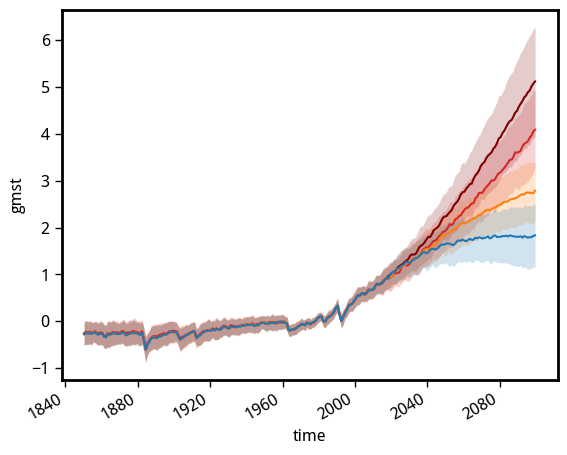

In [34]:
ts5.gmst.mean('model').plot(color='maroon')
plt.fill_between(ts5.time.to_numpy(), ts5.gmst.mean('model') + ts5.gmst.std('model'), ts5.gmst.mean('model') - ts5.gmst.std('model'), color='maroon', alpha=0.2, lw=0.)

ts3.gmst.mean('model').plot(color='tab:red')
plt.fill_between(ts3.time.to_numpy(), ts3.gmst.mean('model') + ts3.gmst.std('model'), ts3.gmst.mean('model') - ts3.gmst.std('model'), color='tab:red', alpha=0.2, lw=0.)

ts2.gmst.mean('model').plot(color='tab:orange')
plt.fill_between(ts2.time.to_numpy(), ts2.gmst.mean('model') + ts2.gmst.std('model'), ts2.gmst.mean('model') - ts2.gmst.std('model'), color='tab:orange', alpha=0.2, lw=0.)

ts1.gmst.mean('model').plot(color='tab:blue')
plt.fill_between(ts1.time.to_numpy(), ts1.gmst.mean('model') + ts1.gmst.std('model'), ts1.gmst.mean('model') - ts1.gmst.std('model'), color='tab:blue', alpha=0.2, lw=0.)

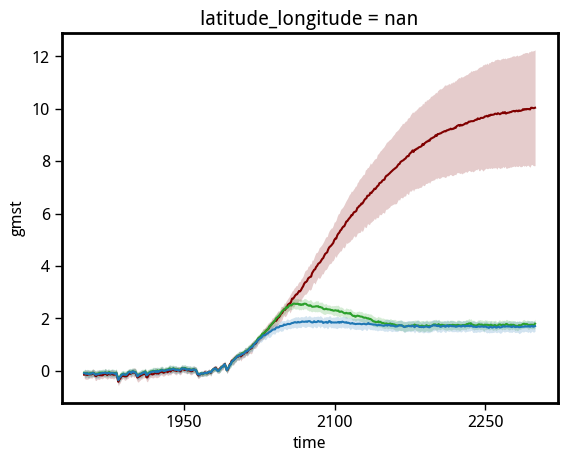

In [35]:
ts5_ext.sel(time = slice('1850','2299')).gmst.mean('model').plot(color='maroon')
plt.fill_between(ts5_ext.sel(time = slice('1850','2299')).time.to_numpy(), ts5_ext.sel(time = slice('1850','2299')).gmst.mean('model') + ts5_ext.sel(time = slice('1850','2299')).gmst.std('model'), ts5_ext.sel(time = slice('1850','2299')).gmst.mean('model') - ts5_ext.sel(time = slice('1850','2299')).gmst.std('model'), color='maroon', alpha=0.2, lw=0.)

ts5o_ext.sel(time = slice('1850','2299')).gmst.mean('model').plot(color='tab:green')
plt.fill_between(ts5o_ext.sel(time = slice('1850','2299')).time.to_numpy(), ts5o_ext.sel(time = slice('1850','2299')).gmst.mean('model') + ts5o_ext.sel(time = slice('1850','2299')).gmst.std('model'), ts5o_ext.sel(time = slice('1850','2299')).gmst.mean('model') - ts5o_ext.sel(time = slice('1850','2299')).gmst.std('model'), color='tab:green', alpha=0.2, lw=0.)

# ts2.gmst.mean('model').plot(color='tab:orange')
# plt.fill_between(ts2.time.to_numpy(), ts2.gmst.mean('model') + ts2.gmst.std('model'), ts2.gmst.mean('model') - ts2.gmst.std('model'), color='tab:orange', alpha=0.2, lw=0.)

ts1_ext.sel(time = slice('1850','2299')).gmst.mean('model').plot(color='tab:blue')
plt.fill_between(ts1_ext.sel(time = slice('1850','2299')).time.to_numpy(), ts1_ext.sel(time = slice('1850','2299')).gmst.mean('model') + ts1_ext.sel(time = slice('1850','2299')).gmst.std('model'), ts1_ext.sel(time = slice('1850','2299')).gmst.mean('model') - ts1_ext.sel(time = slice('1850','2299')).gmst.std('model'), color='tab:blue', alpha=0.2, lw=0.)

In [36]:
# out5_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='maroon')
# plt.fill_between(out5_ext.time.to_numpy(), out5_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out5_ext.nino34_index.rolling(time = 30).std('time').std('model'), out5_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out5_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='maroon', alpha=0.2, lw=0.)

# out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:green')
# plt.fill_between(out5o_ext.time.to_numpy(), out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out5o_ext.nino34_index.rolling(time = 30).std('time').std('model'), out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out5o_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:green', alpha=0.2, lw=0.)

# # out2.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:orange')
# # plt.fill_between(out2.time.to_numpy(), out2.nino34_index.rolling(time = 30).std('time').mean('model') + out2.nino34_index.rolling(time = 30).std('time').std('model'), out2.nino34_index.rolling(time = 30).std('time').mean('model') - out2.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:orange', alpha=0.2, lw=0.)

# out1_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:blue')
# plt.fill_between(out1_ext.time.to_numpy(), out1_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out1_ext.nino34_index.rolling(time = 30).std('time').std('model'), out1_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out1_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:blue', alpha=0.2, lw=0.)

In [37]:
ts5_roll = ts5.rolling(time = 30, center=False).mean('time')
ts3_roll = ts3.rolling(time = 30, center=False).mean('time')
ts2_roll = ts2.rolling(time = 30, center=False).mean('time')
ts1_roll = ts1.rolling(time = 30, center=False).mean('time')

Text(0.5, 1.0, 'ssp126')

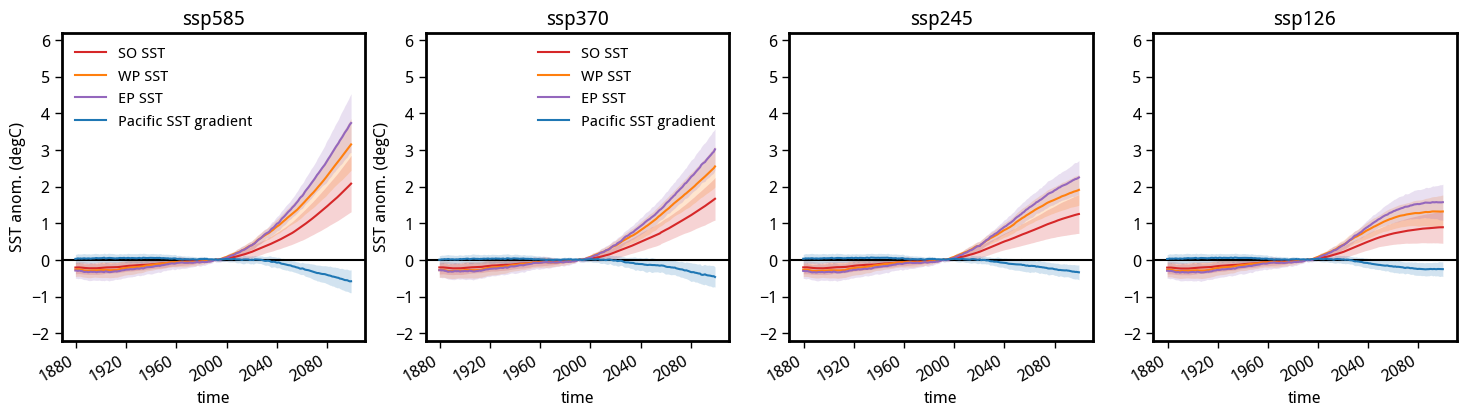

In [38]:
plt.figure(figsize=(18,4))

plt.subplot(141)
plt.axhline(0.0, color='k')
ts5_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.so_sst.mean('model') + ts5_roll.so_sst.std('model'), ts5_roll.so_sst.mean('model') - ts5_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.wp_sst.mean('model') + ts5_roll.wp_sst.std('model'), ts5_roll.wp_sst.mean('model') - ts5_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.ep_sst.mean('model') + ts5_roll.ep_sst.std('model'), ts5_roll.ep_sst.mean('model') - ts5_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5_roll.wp_sst - ts5_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts5_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585')


plt.subplot(142)
plt.axhline(0.0, color='k')
ts3_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.so_sst.mean('model') + ts3_roll.so_sst.std('model'), ts3_roll.so_sst.mean('model') - ts3_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts3_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.wp_sst.mean('model') + ts3_roll.wp_sst.std('model'), ts3_roll.wp_sst.mean('model') - ts3_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts3_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.ep_sst.mean('model') + ts3_roll.ep_sst.std('model'), ts3_roll.ep_sst.mean('model') - ts3_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts3_roll.wp_sst - ts3_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts3_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp370')


plt.subplot(143)
plt.axhline(0.0, color='k')
ts2_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.so_sst.mean('model') + ts2_roll.so_sst.std('model'), ts2_roll.so_sst.mean('model') - ts2_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts2_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.wp_sst.mean('model') + ts2_roll.wp_sst.std('model'), ts2_roll.wp_sst.mean('model') - ts2_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts2_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.ep_sst.mean('model') + ts2_roll.ep_sst.std('model'), ts2_roll.ep_sst.mean('model') - ts2_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts2_roll.wp_sst - ts2_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts2_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp245')


plt.subplot(144)
plt.axhline(0.0, color='k')
ts1_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.so_sst.mean('model') + ts1_roll.so_sst.std('model'), ts1_roll.so_sst.mean('model') - ts1_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts1_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.wp_sst.mean('model') + ts1_roll.wp_sst.std('model'), ts1_roll.wp_sst.mean('model') - ts1_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts1_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.ep_sst.mean('model') + ts1_roll.ep_sst.std('model'), ts1_roll.ep_sst.mean('model') - ts1_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts1_roll.wp_sst - ts1_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts1_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp126')
# plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

In [39]:
ts5_ext_roll = ts5_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')
ts5o_ext_roll = ts5o_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')
ts1_ext_roll = ts1_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')

2025-04-11 00:09:17,901 [WARNING]: legend.py(_parse_legend_args:1217) >> No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'ssp126 extensions')

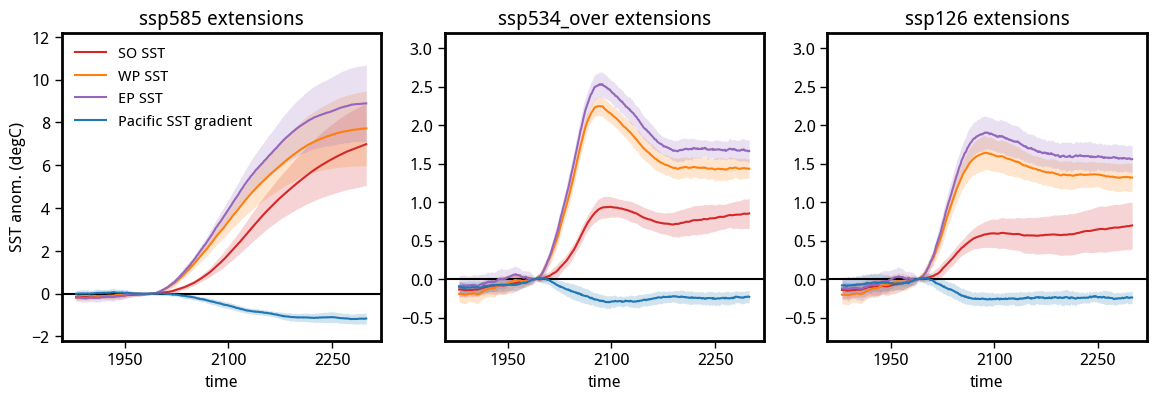

In [40]:
plt.figure(figsize=(14,4))

plt.subplot(131)
plt.axhline(0.0, color='k')
ts5_ext_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.so_sst.mean('model') + ts5_ext_roll.so_sst.std('model'), ts5_ext_roll.so_sst.mean('model') - ts5_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5_ext_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.wp_sst.mean('model') + ts5_ext_roll.wp_sst.std('model'), ts5_ext_roll.wp_sst.mean('model') - ts5_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5_ext_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.ep_sst.mean('model') + ts5_ext_roll.ep_sst.std('model'), ts5_ext_roll.ep_sst.mean('model') - ts5_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5_ext_roll.wp_sst - ts5_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts5_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 12.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585 extensions')


plt.subplot(132)
plt.axhline(0.0, color='k')
ts5o_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.so_sst.mean('model') + ts5o_ext_roll.so_sst.std('model'), ts5o_ext_roll.so_sst.mean('model') - ts5o_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5o_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.wp_sst.mean('model') + ts5o_ext_roll.wp_sst.std('model'), ts5o_ext_roll.wp_sst.mean('model') - ts5o_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5o_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.ep_sst.mean('model') + ts5o_ext_roll.ep_sst.std('model'), ts5o_ext_roll.ep_sst.mean('model') - ts5o_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5o_ext_roll.wp_sst - ts5o_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
# plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp534_over extensions')


plt.subplot(133)
plt.axhline(0.0, color='k')
ts1_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.so_sst.mean('model') + ts1_ext_roll.so_sst.std('model'), ts1_ext_roll.so_sst.mean('model') - ts1_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts1_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.wp_sst.mean('model') + ts1_ext_roll.wp_sst.std('model'), ts1_ext_roll.wp_sst.mean('model') - ts1_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts1_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.ep_sst.mean('model') + ts1_ext_roll.ep_sst.std('model'), ts1_ext_roll.ep_sst.mean('model') - ts1_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts1_ext_roll.wp_sst - ts1_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts1_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
plt.title('ssp126 extensions')
# plt.savefig('./images/cmip_ext_mmm.png', dpi=300, bbox_inches='tight')

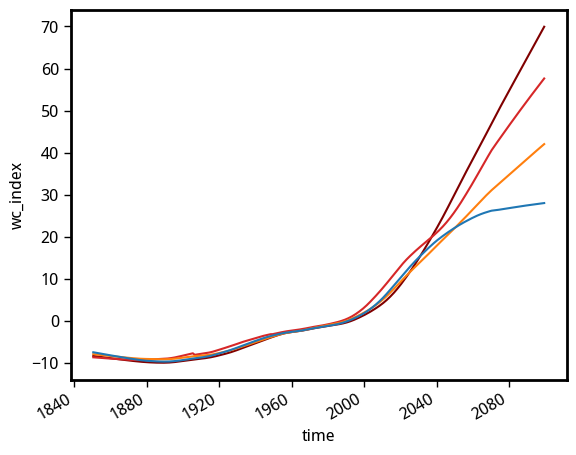

In [41]:
loess3d(psl5.wc_index, dim='time', period=30).mean('model').plot(color='maroon')
loess3d(psl3.wc_index, dim='time', period=30).mean('model').plot(color='tab:red')
loess3d(psl2.wc_index, dim='time', period=30).mean('model').plot(color='tab:orange')
loess3d(psl1.wc_index, dim='time', period=30).mean('model').plot(color='tab:blue')

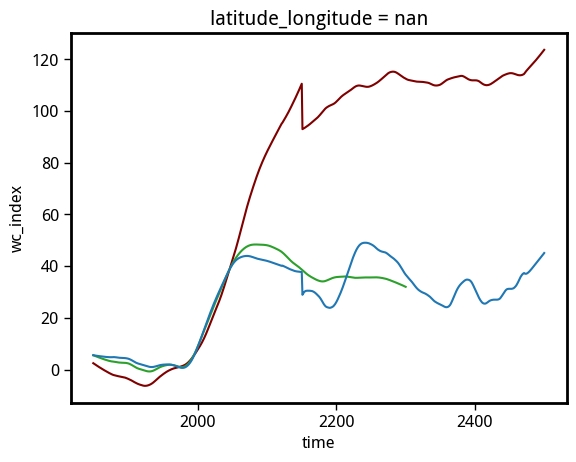

In [42]:
loess3d(psl5_ext.wc_index, dim='time', period=30).mean('model').plot(color='maroon')
loess3d(psl5o_ext.wc_index, dim='time', period=30).mean('model').plot(color='tab:green')
loess3d(psl1_ext.wc_index, dim='time', period=30).mean('model').plot(color='tab:blue')

In [50]:
import seaborn as sns

In [41]:
so_warming1 = ts1.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming1 = ts1.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming1 = ts1.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad1 = ts1.wp_sst - ts1.ep_sst
grad_weakening1 = sst_grad1.sel(time = slice('2050', '2100')).mean('time')

In [42]:
so_warming2 = ts2.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming2 = ts2.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming2 = ts2.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad2 = ts2.wp_sst - ts2.ep_sst
grad_weakening2 = sst_grad2.sel(time = slice('2050', '2100')).mean('time')

In [43]:
so_warming3 = ts3.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming3 = ts3.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming3 = ts3.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad3 = ts3.wp_sst - ts3.ep_sst
grad_weakening3 = sst_grad3.sel(time = slice('2050', '2100')).mean('time')

In [44]:
so_warming5 = ts5.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming5 = ts5.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming5 = ts5.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad5 = ts5.wp_sst - ts5.ep_sst
grad_weakening5 = sst_grad5.sel(time = slice('2050', '2100')).mean('time')

In [45]:
so_warming5o = ts5o_ext.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming5o = ts5o_ext.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming5o = ts5o_ext.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad5o = ts5o_ext.wp_sst - ts5o_ext.ep_sst
grad_weakening5o = sst_grad5o.sel(time = slice('2050', '2100')).mean('time')

In [46]:
so_warming = np.concatenate((so_warming1, so_warming2, so_warming3, so_warming5o, so_warming5))
np_warming = np.concatenate((np_warming1, np_warming2, np_warming3, np_warming5o, np_warming5))
grad_weakening = np.concatenate((grad_weakening1, grad_weakening2, grad_weakening3, grad_weakening5o, grad_weakening5))
gmst_warming = np.concatenate((gmst_warming1, gmst_warming2, grad_weakening3, gmst_warming5o, gmst_warming5))

In [47]:
grad_weakening.shape

(216,)

In [48]:
so_warming1.quantile(0.75)

<xarray.DataArray 'so_sst' ()>
array(1.12346865)
Coordinates:
    quantile  float64 0.75

SignificanceResult(statistic=-0.30696437672364923, pvalue=4.2918899749402885e-06)

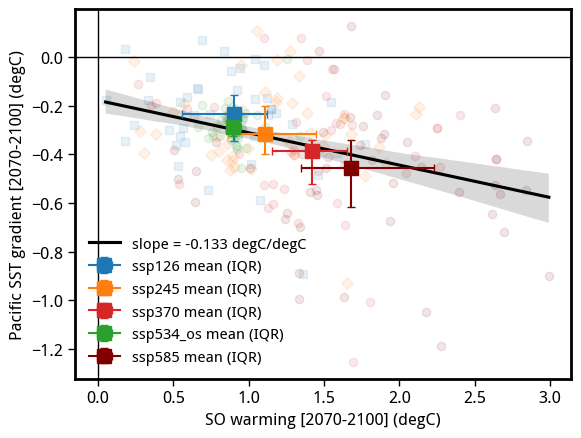

In [51]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(so_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.1)
plt.scatter(so_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.1)
plt.scatter(so_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.1)
plt.scatter(so_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.1)
plt.scatter(so_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.1)
reg_res = stats.linregress(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])
sns.regplot(x=so_warming, y=grad_weakening, scatter=False, color='k', label = f'slope = {np.round(reg_res.slope, 3)} degC/degC')

median_x = so_warming1.quantile(0.5)
median_y = grad_weakening1.quantile(0.5)
lq_x = so_warming1.quantile(0.25)
lq_y = grad_weakening1.quantile(0.25)
uq_x = so_warming1.quantile(0.75)
uq_y = grad_weakening1.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:blue', label='ssp126 mean (IQR)')

median_x = so_warming2.quantile(0.5)
median_y = grad_weakening2.quantile(0.5)
lq_x = so_warming2.quantile(0.25)
lq_y = grad_weakening2.quantile(0.25)
uq_x = so_warming2.quantile(0.75)
uq_y = grad_weakening2.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:orange', label='ssp245 mean (IQR)')


median_x = so_warming3.quantile(0.5)
median_y = grad_weakening3.quantile(0.5)
lq_x = so_warming3.quantile(0.25)
lq_y = grad_weakening3.quantile(0.25)
uq_x = so_warming3.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:red', label='ssp370 mean (IQR)')


median_x = so_warming5o.quantile(0.5)
median_y = grad_weakening5o.quantile(0.5)
lq_x = so_warming5o.quantile(0.25)
lq_y = grad_weakening5o.quantile(0.25)
uq_x = so_warming5o.quantile(0.75)
uq_y = grad_weakening5o.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:green', label='ssp534_os mean (IQR)')

median_x = so_warming5.quantile(0.5)
median_y = grad_weakening5.quantile(0.5)
lq_x = so_warming5.quantile(0.25)
lq_y = grad_weakening5.quantile(0.25)
uq_x = so_warming5.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='maroon', label='ssp585 mean (IQR)')


plt.ylabel('Pacific SST gradient [2070-2100] (degC)')
plt.xlabel('SO warming [2070-2100] (degC)')
plt.legend(frameon=False, fontsize=11)
# plt.savefig('./images/so_warming_sst_grad_relationship.png', dpi=300, bbox_inches='tight')
stats.spearmanr(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])

SignificanceResult(statistic=-0.3228695813705363, pvalue=1.246300734732634e-06)

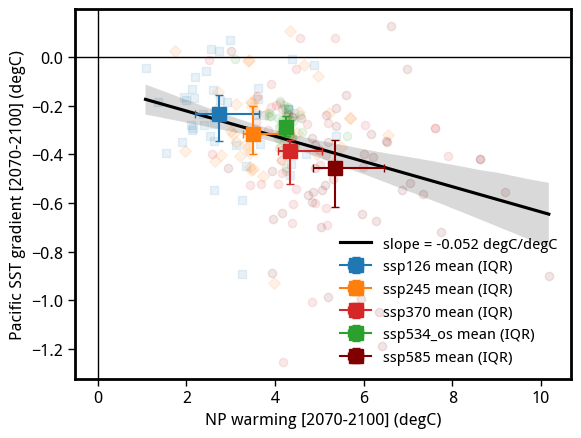

In [52]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(np_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.1)
plt.scatter(np_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.1)
plt.scatter(np_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.1)
plt.scatter(np_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.1)
plt.scatter(np_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.1)
reg_res = stats.linregress(np_warming[~(np.isnan(np_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(np_warming) | np.isnan(grad_weakening))])
sns.regplot(x=np_warming, y=grad_weakening, scatter=False, color='k', label = f'slope = {np.round(reg_res.slope, 3)} degC/degC')

median_x = np_warming1.quantile(0.5)
median_y = grad_weakening1.quantile(0.5)
lq_x = np_warming1.quantile(0.25)
lq_y = grad_weakening1.quantile(0.25)
uq_x = np_warming1.quantile(0.75)
uq_y = grad_weakening1.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:blue', label='ssp126 mean (IQR)')

median_x = np_warming2.quantile(0.5)
median_y = grad_weakening2.quantile(0.5)
lq_x = np_warming2.quantile(0.25)
lq_y = grad_weakening2.quantile(0.25)
uq_x = np_warming2.quantile(0.75)
uq_y = grad_weakening2.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:orange', label='ssp245 mean (IQR)')


median_x = np_warming3.quantile(0.5)
median_y = grad_weakening3.quantile(0.5)
lq_x = np_warming3.quantile(0.25)
lq_y = grad_weakening3.quantile(0.25)
uq_x = np_warming3.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:red', label='ssp370 mean (IQR)')


median_x = np_warming5o.quantile(0.5)
median_y = grad_weakening5o.quantile(0.5)
lq_x = np_warming5o.quantile(0.25)
lq_y = grad_weakening5o.quantile(0.25)
uq_x = np_warming5o.quantile(0.75)
uq_y = grad_weakening5o.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:green', label='ssp534_os mean (IQR)')

median_x = np_warming5.quantile(0.5)
median_y = grad_weakening5.quantile(0.5)
lq_x = np_warming5.quantile(0.25)
lq_y = grad_weakening5.quantile(0.25)
uq_x = np_warming5.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='maroon', label='ssp585 mean (IQR)')


plt.ylabel('Pacific SST gradient [2070-2100] (degC)')
plt.xlabel('NP warming [2070-2100] (degC)')
plt.legend(frameon=False, fontsize=11)
# plt.savefig('./images/np_warming_sst_grad_relationship.png', dpi=300, bbox_inches='tight')
stats.spearmanr(np_warming[~(np.isnan(np_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(np_warming) | np.isnan(grad_weakening))])

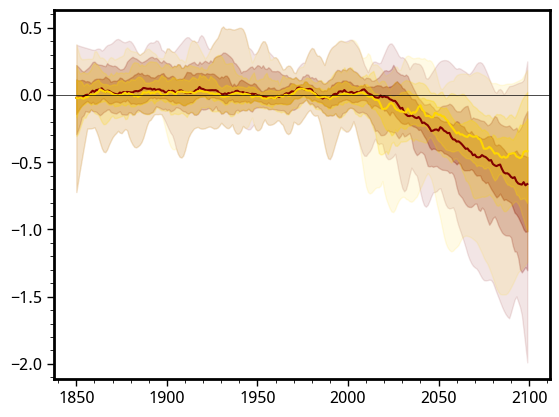

In [53]:
plt.plot(sst_grad5.time.dt.year, loess3d(sst_grad5, dim='time', period=10).quantile(0.5, 'model'), color='maroon')
plt.fill_between(sst_grad5.time.dt.year, loess3d(sst_grad5, dim='time', period=10).quantile(0.25, 'model'), loess3d(sst_grad5, dim='time', period=10).quantile(0.75, 'model'), alpha=0.3, color='maroon')
plt.fill_between(sst_grad5.time.dt.year, loess3d(sst_grad5, dim='time', period=10).quantile(0.1, 'model'), loess3d(sst_grad5, dim='time', period=10).quantile(0.9, 'model'), alpha=0.2, color='maroon')
plt.fill_between(sst_grad5.time.dt.year, loess3d(sst_grad5, dim='time', period=10).min('model'), loess3d(sst_grad5, dim='time', period=10).max('model'), alpha=0.1, color='maroon')

plt.plot(sst_grad3.time.dt.year, loess3d(sst_grad3, dim='time', period=10).quantile(0.5, 'model'), color='gold')
plt.fill_between(sst_grad3.time.dt.year, loess3d(sst_grad3, dim='time', period=10).quantile(0.25, 'model'), loess3d(sst_grad3, dim='time', period=10).quantile(0.75, 'model'), alpha=0.3, color='gold')
plt.fill_between(sst_grad3.time.dt.year, loess3d(sst_grad3, dim='time', period=10).quantile(0.1, 'model'), loess3d(sst_grad3, dim='time', period=10).quantile(0.9, 'model'), alpha=0.2, color='gold')
plt.fill_between(sst_grad3.time.dt.year, loess3d(sst_grad3, dim='time', period=10).min('model'), loess3d(sst_grad3, dim='time', period=10).max('model'), alpha=0.1, color='gold')

plt.minorticks_on()
plt.axhline(0.0, color='k', lw=0.5)

In [60]:
# test0 = (ts5.np_sst - ts5.so_sst).sel(time = slice('2000', '2014')).mean('time') - (ts5.np_sst - ts5.so_sst).sel(time = slice('1950', '1970')).mean('time')
hist_mean_state_changes = sst_grad5.sel(time = slice('2000', '2014')).mean('time') - sst_grad5.sel(time = slice('1950', '1970')).mean('time')
early_changes = sst_grad5.sel(time = slice('2015', '2035')).mean('time')
mid_changes = sst_grad5.sel(time = slice('2040', '2070')).mean('time')
late_changes = sst_grad5.sel(time = slice('2080', '2100')).mean('time')


In [61]:
df = pd.DataFrame(data=dict(hist=hist_mean_state_changes.to_numpy(), early = early_changes.to_numpy(), med=mid_changes.to_numpy(), late = late_changes.to_numpy()))

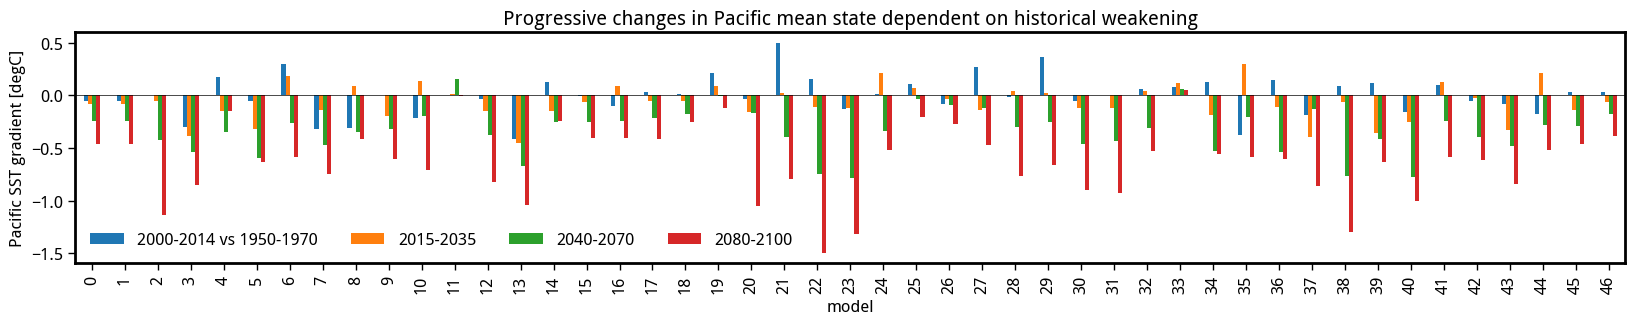

In [62]:
df.plot.bar(figsize=(20,3))
plt.xlabel('model')
plt.ylabel('Pacific SST gradient [degC]')
plt.title('Progressive changes in Pacific mean state dependent on historical weakening')
ax = plt.gca()
ax.legend(["2000-2014 vs 1950-1970", "2015-2035", "2040-2070", "2080-2100"], frameon=False, ncol=5)
plt.axhline(0.0, lw=0.5, color='k')

In [63]:
weights = np.cos(np.deg2rad(ts5.ts.lat))
weights

<xarray.DataArray 'lat' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [ ]:
ts5.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'))

In [ ]:
plot_list = [
    ts5.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.9, 'model'))
]

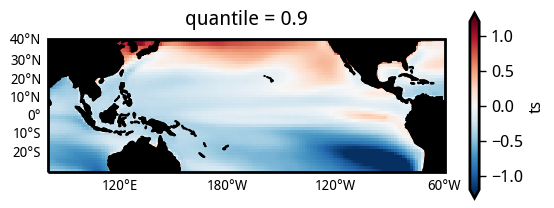

In [58]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
plt_test = ts5.ts.where(test1 > test1.quantile(0.90, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-30, 40), lon = slice(80, -60+360))
(plt_test - plt_test.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-1.2, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=1.0)

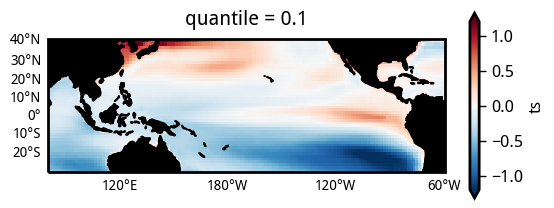

In [59]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
plt_test = ts5.ts.where(test1 < test1.quantile(0.10, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-30, 40), lon = slice(80, -60+360))
(plt_test - plt_test.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-1.2, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=1.0)

Text(0, 0.5, 'SO warming [degC]')

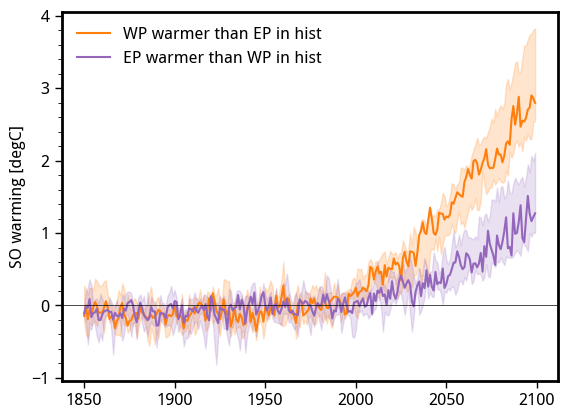

In [181]:
plt_test1 = ts5.so_sst.where(test1 > test1.quantile(0.90, 'model'), drop=True)
plt_test2 = ts5.so_sst.where(test1 < test1.quantile(0.10, 'model'), drop=True)
plt.plot(ts5.time.dt.year, plt_test1.quantile(0.5, 'model'), color='tab:orange', label='WP warmer than EP in hist')
plt.fill_between(ts5.time.dt.year, plt_test1.quantile(0.1, 'model'), plt_test1.quantile(0.9, 'model'), color='tab:orange', alpha=0.2)

plt.plot(ts5.time.dt.year, plt_test2.quantile(0.5, 'model'), color='tab:purple', label='EP warmer than WP in hist')
plt.fill_between(ts5.time.dt.year, plt_test2.quantile(0.1, 'model'), plt_test2.quantile(0.9, 'model'), color='tab:purple', alpha=0.2)
plt.legend(frameon=False, fontsize=12, loc='upper left')
plt.minorticks_on()
plt.gca().tick_params(which='minor', axis='x', bottom=False)
plt.axhline(0.0, lw=0.5, color='k')
plt.ylabel('SO warming [degC]')

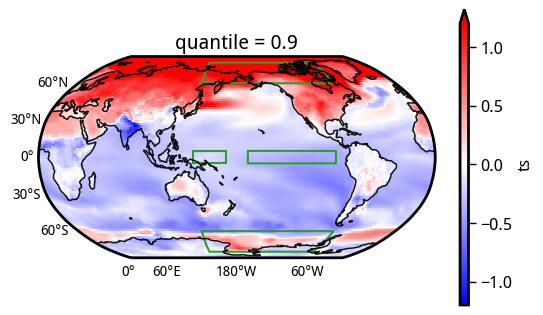

In [182]:
# ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200, central_latitude=-20))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plt_test1 = ts5.ts.where(test1 >= test1.quantile(0.90, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))#.sel(lon = slice(110, 300))
# (plt_test1).plot(transform=ccrs.PlateCarree(), vmin=-3.2, vmax=3.2, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
# levels=np.concatenate((np.arange(-3.0, -0.2, 0.2), np.arange(0.4, 3.2, 0.2)))
(plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-1.2, vmax=1.2, cmap='bwr', cbar_kwargs=dict(shrink=0.8, aspect=35))
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)
ax.add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='tab:green', lw = 1.5,
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='tab:green', lw=1.5,
                                transform=ccrs.PlateCarree()))

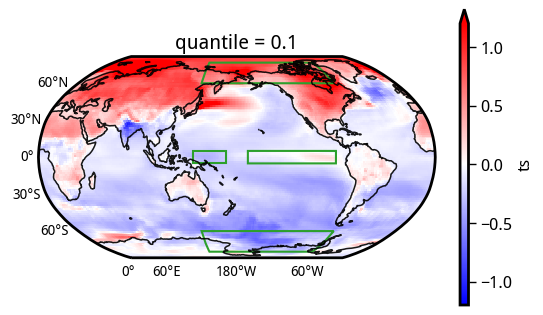

In [184]:
# ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200, central_latitude=-20))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plt_test2 = ts5.ts.where(test1 <= test1.quantile(0.10, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))#.sel(lon = slice(110, 300))
# (plt_test1).plot(transform=ccrs.PlateCarree(), vmin=-3.2, vmax=3.2, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
# levels=np.concatenate((np.arange(-3.0, -0.2, 0.2), np.arange(0.4, 3.2, 0.2)))
(plt_test2 - plt_test2.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-1.2, vmax=1.2, cmap='bwr', cbar_kwargs=dict(shrink=0.8, aspect=35))
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)
ax.add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='tab:green', lw = 1.5,
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='tab:green', lw=1.5,
                                transform=ccrs.PlateCarree()))

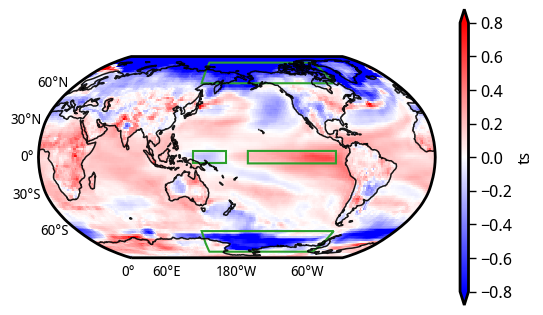

In [185]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
# (plt_test1).plot(transform=ccrs.PlateCarree(), vmin=-3.2, vmax=3.2, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
# levels=np.concatenate((np.arange(-2.0, -0.0, 0.2), np.arange(0.2, 2.2, 0.2)))
((plt_test2 - plt_test2.weighted(weights).mean(('lat', 'lon'))) - (plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon')))).plot(transform=ccrs.PlateCarree(), vmin=-0.8, vmax=0.8, cmap='bwr', cbar_kwargs=dict(shrink=0.8, aspect=35))
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)
ax.add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
                                            facecolor='none', edgecolor='tab:green', lw=1.5,
                                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='tab:green', lw = 1.5,
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='tab:green', lw=1.5,
                                transform=ccrs.PlateCarree()))

In [150]:
rel_ts5 = ts5.ts - ts5.ts.weighted(weights).mean(('lat', 'lon'))
rel_ts5

<xarray.DataArray 'ts' (model: 47, time: 250, lat: 120, lon: 240)>
array([[[[-1.30917044e+00, -1.32401724e+00, -1.33550711e+00, ...,
          -1.27265616e+00, -1.28559561e+00, -1.29588004e+00],
         [-1.30917044e+00, -1.32401724e+00, -1.33550711e+00, ...,
          -1.27265616e+00, -1.28559561e+00, -1.29588004e+00],
         [-1.49667044e+00, -1.52247305e+00, -1.54256888e+00, ...,
          -1.46265860e+00, -1.48763724e+00, -1.49154349e+00],
         ...,
         [-1.03181143e+00, -1.05588980e+00, -1.07459708e+00, ...,
          -9.75750641e-01, -9.90338043e-01, -1.00848074e+00],
         [-7.97238067e-01, -8.06317047e-01, -8.13336090e-01, ...,
          -7.58282379e-01, -7.76211456e-01, -7.85427765e-01],
         [-7.97238067e-01, -8.06317047e-01, -8.13336090e-01, ...,
          -7.58282379e-01, -7.76211456e-01, -7.85427765e-01]],

        [[-9.62522063e-01, -9.57196746e-01, -9.52985320e-01, ...,
          -9.38901458e-01, -9.49719939e-01, -9.55319915e-01],
         [-9.62522063e-01, -9.57196746e-01, -9.52985320e-01, ...,
          -9.38901458e-01, -9.49719939e-01, -9.55319915e-01],
         [-7.86222014e-01, -7.83139739e-01, -7.80759368e-01, ...,
          -7.54804168e-01, -7.63547454e-01, -7.73480925e-01],
...
         [ 6.22331250e+00,  6.25105298e+00,  6.28266919e+00, ...,
           6.14176953e+00,  6.17625439e+00,  6.19889844e+00],
         [ 6.19804394e+00,  6.21293652e+00,  6.23036206e+00, ...,
           6.14802563e+00,  6.16343701e+00,  6.18269360e+00],
         [ 6.06956494e+00,  6.08842480e+00,  6.10026562e+00, ...,
           6.06153882e+00,  6.06364453e+00,  6.06517041e+00]],

        [[ 1.86223939e+00,  1.88337282e+00,  1.88860658e+00, ...,
           1.86693910e+00,  1.85651735e+00,  1.86344484e+00],
         [ 1.64995912e+00,  1.66109804e+00,  1.66837648e+00, ...,
           1.62617067e+00,  1.63393739e+00,  1.64654115e+00],
         [ 1.38036683e+00,  1.39074281e+00,  1.39028505e+00, ...,
           1.34914735e+00,  1.36036256e+00,  1.37031129e+00],
         ...,
         [ 7.19388917e+00,  7.19657472e+00,  7.19901613e+00, ...,
           7.16318849e+00,  7.18308595e+00,  7.19288209e+00],
         [ 7.00989869e+00,  7.00950197e+00,  7.00971559e+00, ...,
           6.98597291e+00,  6.99158815e+00,  7.00370363e+00],
         [ 6.71540407e+00,  6.72956422e+00,  6.73710206e+00, ...,
           6.71110109e+00,  6.71146730e+00,  6.71229127e+00]]]])
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'

In [186]:
mer_grad5 = rel_ts5.sel(lat = slice(60, 90), lon = slice(140, 290)).weighted(weights).mean(('lat', 'lon')) - rel_ts5.sel(lat = slice(-80, -60), lon = slice(140, 290)).weighted(weights).mean(('lat', 'lon'))
mer_grad5

<xarray.DataArray 'ts' (model: 47, time: 250)>
array([[ 0.94272313,  0.07315388, -0.67638958, ..., 11.41799042,
        11.58447489, 12.00473553],
       [ 0.94272313,  0.07315388, -0.67638958, ..., 11.41799042,
        11.58447489, 12.00473553],
       [ 2.14231385,  1.13336746,  1.13100897, ..., 12.32359629,
        11.89679892, 11.08357532],
       ...,
       [-0.58537616, -0.13405808,  1.54203756, ...,  5.34552936,
         4.83005743,  4.49930553],
       [ 0.62822886,  2.16507917,  0.71587377, ...,  8.21695568,
         8.00067288,  9.33502835],
       [ 0.66105279,  0.62946457,  1.29690849, ...,  5.53336031,
         6.03004174,  6.8028087 ]])
Coordinates:
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'

In [187]:
zon_pac_grad5 = rel_ts5.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - rel_ts5.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

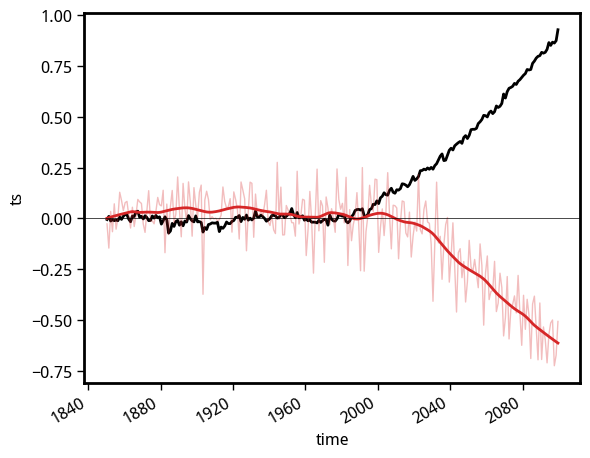

In [188]:
test1 = (mer_grad5.mean('model')/(mer_grad5.mean('model').max('time') - mer_grad5.mean('model').min('time')))
test1.plot(color='k', lw=2.0)
test2 = (zon_pac_grad5.mean('model')/(zon_pac_grad5.mean('model').max('time') - zon_pac_grad5.mean('model').min('time')))
test2.plot(color='tab:red', lw=1.0, alpha=0.3)
loess3d(test2, dim='time', period=15).plot(color='tab:red', lw=2.0)
plt.axhline(0.0, lw=0.5, color='k')

PearsonRResult(statistic=0.17213597647480774, pvalue=0.24727706990967743)

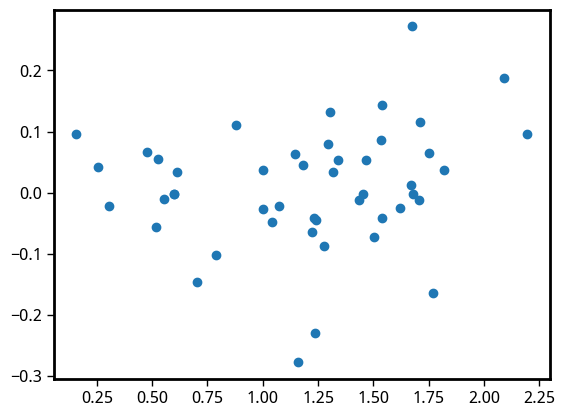

In [196]:
xval = mer_grad5.sel(time = slice('2000', '2014')).mean('time')# - mer_grad5.sel(time = slice('1950', '1970')).mean('time')
yval = loess3d(zon_pac_grad5, dim='time', period=15).sel(time = slice('2000', '2014')).mean('time')# - loess3d(zon_pac_grad5, dim='time', period=15).sel(time = slice('1950', '1970')).mean('time')
plt.scatter(xval, yval)
stats.pearsonr(xval, yval)

In [197]:
uas5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/uas_ssp5.nc')
uas5

<xarray.Dataset>
Dimensions:             (time: 250, lon: 240, lat: 120, model: 37)
Coordinates:
    height              float64 ...
  * time                (time) datetime64[ns] 1850-06-01 ... 2099-06-01
    latitude_longitude  float64 ...
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * model               (model) object 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'NESM3'
Data variables:
    uas                 (model, time, lat, lon) float32 ...

In [198]:
vas5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/vas_ssp5.nc')
vas5

<xarray.Dataset>
Dimensions:             (time: 250, lon: 240, lat: 120, model: 37)
Coordinates:
    height              float64 ...
  * time                (time) datetime64[ns] 1850-06-01 ... 2099-06-01
    latitude_longitude  float64 ...
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * model               (model) object 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'NESM3'
Data variables:
    vas                 (model, time, lat, lon) float32 ...

In [199]:
uas5_anom = funcs.calc_anom(uas5.uas, uas5.uas.sel(time = slice('1960', '1990')))
vas5_anom = funcs.calc_anom(vas5.vas, vas5.vas.sel(time = slice('1960', '1990')))

<GeoAxesSubplot:title={'center':'quantile = 0.9'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

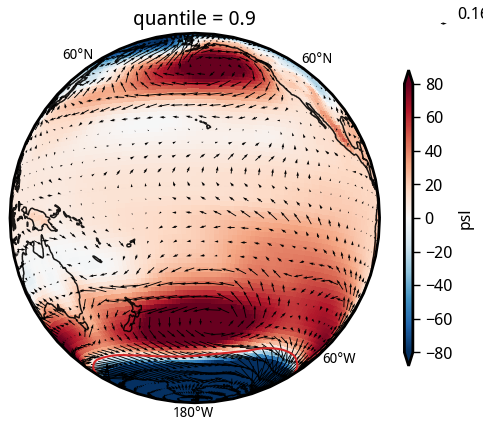

In [240]:
# ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200, central_latitude=-10))
plt_test1 = psl5.psl.where(test1 > test1.quantile(0.90, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))#.sel(lat = slice(-80, 80))
# (plt_test1).plot(transform=ccrs.PlateCarree(), vmin=-140, vmax=140, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.5))
# (plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-140, vmax=140, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.8, aspect=35))
(plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-80, vmax=80, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.8, aspect=35))
(plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon'))).sel(lat = slice(-70, -50)).plot.contour(transform=ccrs.PlateCarree(), colors='tab:red', levels=[0],)
plt_test1_wnd = xr.merge([uas5_anom.where(test1 > test1.quantile(0.90, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model')), \
                          vas5_anom.where(test1 > test1.quantile(0.90, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))]).isel(lon = slice(0,-1,3), lat = slice(0,-1,3))
plt_test1_wnd.plot.quiver(x="lon", y="lat", u="uas", v="vas", color='k', vmin=0, vmax=1, extend='both', scale=10, robust=True, transform=ccrs.PlateCarree())
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)

<GeoAxesSubplot:title={'center':'quantile = 0.1'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

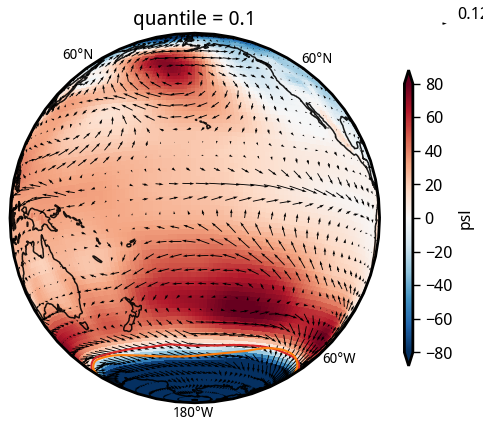

In [241]:
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200, central_latitude=-10))
# ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plt_test2 = psl5.psl.where(test1 < test1.quantile(0.10, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))
# (plt_test2).plot(transform=ccrs.PlateCarree(), vmin=-140, vmax=140, cmap='BrBG_r', cbar_kwargs=dict(shrink=0.5))
(plt_test2 - plt_test2.weighted(weights).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-80, vmax=80, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.8, aspect=35))
(plt_test2 - plt_test2.weighted(weights).mean(('lat', 'lon'))).sel(lat = slice(-70, -50)).plot.contour(transform=ccrs.PlateCarree(), colors='tab:red', levels=[0],)
(plt_test1 - plt_test1.weighted(weights).mean(('lat', 'lon'))).sel(lat = slice(-70, -50)).plot.contour(transform=ccrs.PlateCarree(), colors='tab:orange', ls='--', levels=[0],)
plt_test2_wnd = xr.merge([uas5_anom.where(test1 < test1.quantile(0.10, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model')), \
                          vas5_anom.where(test1 < test1.quantile(0.10, 'model'), drop=True).sel(time = slice('2000', '2014')).mean(('time', 'model'))]).isel(lon = slice(0,-1,3), lat = slice(0,-1,3))
plt_test2_wnd.plot.quiver(x="lon", y="lat", u="uas", v="vas", color='k', vmin=0, vmax=1, extend='both', scale=10, robust=True, transform=ccrs.PlateCarree())
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)

<GeoAxesSubplot:xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

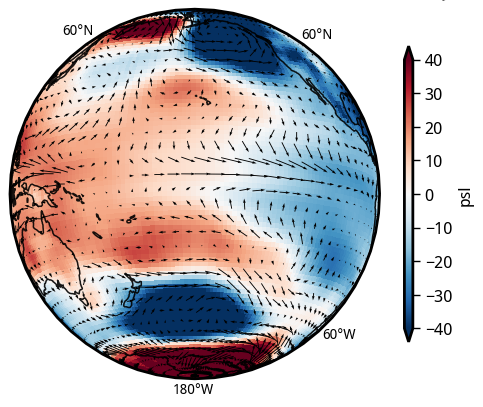

In [242]:
# ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200, central_latitude=-10))
((plt_test2 - plt_test1) - (plt_test2 - plt_test1).mean(('lat', 'lon'))).plot(transform=ccrs.PlateCarree(), vmin=-40, vmax=40, cmap='RdBu_r', cbar_kwargs=dict(shrink=0.8, aspect=35))
(plt_test2_wnd - plt_test1_wnd).plot.quiver(x="lon", y="lat", u="uas", v="vas", color='k', vmin=0, vmax=0.4, extend='both', scale=10, robust=True, transform=ccrs.PlateCarree())
plot_background(ax)
# ax.add_feature(cfeature.LAND, color='k', zorder=1.0)

## OLD

In [6]:
def find_signal_exceeds_noise(signal, noise, weight=1, invert=True):
    if invert:
        # signal = loess1d(arr, period=period)
        # noise = test - signal
        std_noise = np.std(noise)  # Find the maximum value of the noise array
        for i in range(len(signal)):
            if signal[i] <= -weight*std_noise:
                # Check if the signal stays above the noise max for the rest of the array
                if all(signal[j] <= -weight*std_noise for j in range(i, len(signal))):
                    return i  # Return the first index where the condition is met
        return -1  # Return -1 if no such index exists
    else:
        # signal = loess1d(arr, period=period)
        # noise = test - signal
        # max_noise = np.max(noise)  # Find the maximum value of the noise array
        std_noise = np.std(noise)
        for i in range(len(signal)):
            if signal[i] >= weight*std_noise:
                # Check if the signal stays above the noise max for the rest of the array
                if all(signal[j] >= weight*std_noise for j in range(i, len(signal))):
                    return i  # Return the first index where the condition is met
        return -1  # Return -1 if no such index exists



def find_signal_exceeds_noise3d(da, dim, weight=1, invert=True):
    signa_da = loess3d(da, dim='time', period=31)
    noise_da = da - signa_da
    return da.time.dt.year[xr.apply_ufunc(find_signal_exceeds_noise, signa_da, noise_da, input_core_dims=[[dim], [dim]], kwargs=dict(weight=weight, invert=invert), vectorize=True, dask='allowed')]


In [81]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [82]:
toe5 = find_signal_exceeds_noise3d(ts5.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)
toe3 = find_signal_exceeds_noise3d(ts3.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)
toe2 = find_signal_exceeds_noise3d(ts2.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)
toe1 = find_signal_exceeds_noise3d(ts1.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)

In [ ]:
toe5_ext = find_signal_exceeds_noise3d(ts5_ext.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)
toe5o_ext = find_signal_exceeds_noise3d(ts5o_ext.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)
toe1_ext = find_signal_exceeds_noise3d(ts1_ext.dropna('model').so_sst.isel(time = slice(1,-1)), dim='time', invert=False)

In [ ]:
sst_grad5_ext = ts5_ext.wp_sst - ts5_ext.ep_sst
sst_grad5o_ext = ts5o_ext.wp_sst - ts5o_ext.ep_sst
sst_grad1_ext = ts1_ext.wp_sst - ts1_ext.ep_sst

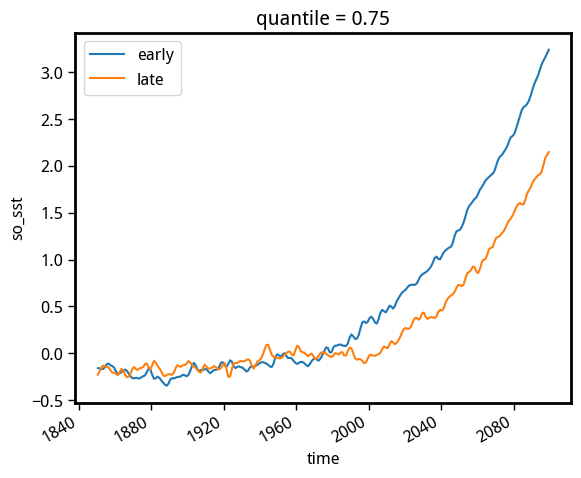

In [ ]:
loess3d(ts5.so_sst, period=2, dim='time').where(toe5 <= toe5.quantile(0.25), drop=False).mean('model').plot(label='early')
loess3d(ts5.so_sst, period=2, dim='time').where(toe5 >= toe5.quantile(0.75), drop=False).mean('model').plot(label='late')
plt.legend()

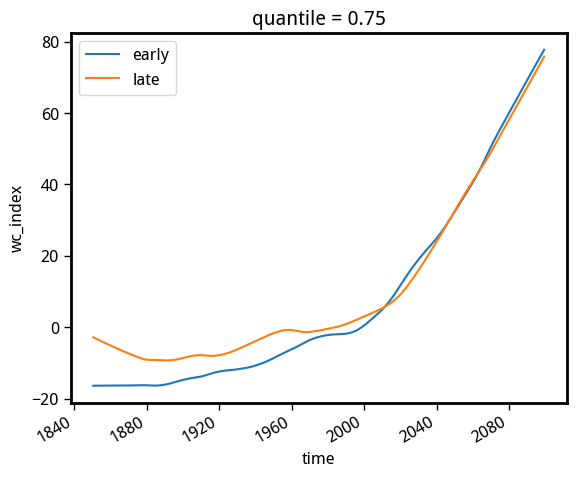

In [ ]:
loess3d(psl5.wc_index, period=30, dim='time').where(toe5 <= toe5.quantile(0.25), drop=False).mean('model').plot(label='early')
loess3d(psl5.wc_index, period=30, dim='time').where(toe5 >= toe5.quantile(0.75), drop=False).mean('model').plot(label='late')
plt.legend()

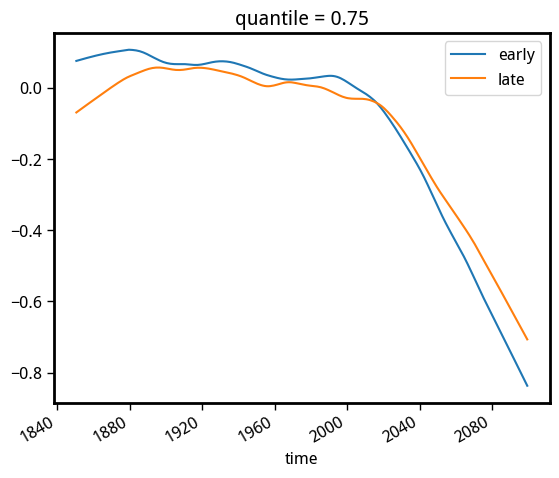

In [ ]:
loess3d(sst_grad5, period=30, dim='time').where(toe5 <= toe5.quantile(0.25), drop=False).mean('model').plot(label='early')
loess3d(sst_grad5, period=30, dim='time').where(toe5 >= toe5.quantile(0.75), drop=False).mean('model').plot(label='late')
plt.legend()

In [ ]:
def get_temporal_causality(toe_arr, sst_grad_arr, prev_year_gap = 30, post_year_gap = 50):
    sst_grad_arr = sst_grad_arr.where((toe_arr <= 2090) & (toe_arr >= 1860))
    toe_arr = toe_arr.where((toe_arr <= 2090) & (toe_arr >= 1860))
    temporal_causality = np.empty((len(toe_arr.model), prev_year_gap + post_year_gap))
    for i in range(len(toe_arr.model)):
        toe_year = float(toe_arr.isel(model=i))
        try:
            temporal_causality[i, :] = sst_grad_arr.isel(model = i).where(sst_grad_arr.time.dt.year.isin(np.arange(toe_year - prev_year_gap, toe_year + post_year_gap, 1)), drop=True)
        except ValueError:
            temporal_causality[i, :] = np.empty((prev_year_gap+post_year_gap))
    return temporal_causality

In [ ]:
temporal_causality5 = get_temporal_causality(toe5, loess3d(sst_grad5, dim='time', period=30))
temporal_causality3 = get_temporal_causality(toe3, loess3d(sst_grad3, dim='time', period=30))
temporal_causality2 = get_temporal_causality(toe2, loess3d(sst_grad2, dim='time', period=30))
temporal_causality1 = get_temporal_causality(toe1, loess3d(sst_grad1, dim='time', period=30))
# temporal_causality5o = get_temporal_causality(toe5o, loess3d(sst_grad5o, dim='time', period=30))

In [ ]:
temporal_causality5_ext = get_temporal_causality(toe5_ext, loess3d(sst_grad5_ext, dim='time', period=30))
temporal_causality5o_ext = get_temporal_causality(toe5o_ext, loess3d(sst_grad5o_ext, dim='time', period=30))
temporal_causality1_ext = get_temporal_causality(toe1_ext, loess3d(sst_grad1_ext, dim='time', period=30))

In [ ]:
def plot_temporal_causality(temporal_causality_arr, color, min=-30, max=50, **kwargs):
    median_evol = np.quantile(temporal_causality_arr, 0.5, axis=0)
    uq_evol = np.quantile(temporal_causality_arr, 0.75, axis=0)
    lq_evol = np.quantile(temporal_causality_arr, 0.25, axis=0)
    plt.plot(np.arange(min, max, 1), loess1d(median_evol, period=30), color=color, lw=2.0, **kwargs)
    plt.fill_between(np.arange(min, max, 1), y1 = loess1d(lq_evol, period=30), y2=loess1d(uq_evol, period=15), alpha=0.1, color=color)
    plt.axvline(0.0, color='k', lw=0.5)
    plt.axhline(0.0, color='k', lw=0.5)

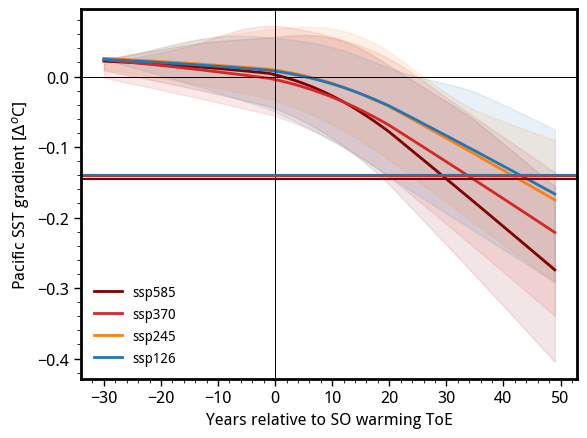

In [ ]:
plot_temporal_causality(temporal_causality5, color='maroon', label='ssp585')
plot_temporal_causality(temporal_causality3, color='tab:red', label='ssp370')
plot_temporal_causality(temporal_causality2, color='tab:orange', label='ssp245')
# plot_temporal_causality(temporal_causality1, color='tab:blue', min=-30, max=2)
plot_temporal_causality(temporal_causality1, color='tab:blue', ls='-', label='ssp126')
# plot_temporal_causality(temporal_causality5o_ext, color='tab:green', label='ssp534_over')
plt.legend(frameon=False, fontsize=10)
plt.minorticks_on()
plt.ylabel('Pacific SST gradient [$\Delta ^{o}$C]')
plt.xlabel('Years relative to SO warming ToE')

plt.axhline(-0.2*((sst_grad5 - loess3d(sst_grad5, dim='time', period=30)).std('time')).median('model'), color='maroon')
plt.axhline(-0.2*((sst_grad3 - loess3d(sst_grad3, dim='time', period=30)).std('time')).median('model'), color='tab:red')
plt.axhline(-0.2*((sst_grad2 - loess3d(sst_grad2, dim='time', period=30)).std('time')).median('model'), color='tab:orange')
plt.axhline(-0.2*((sst_grad1 - loess3d(sst_grad1, dim='time', period=30)).std('time')).median('model'), color='tab:blue')
# plt.axhline(-0.2*((sst_grad5o_ext - loess3d(sst_grad5o_ext, dim='time', period=30)).std('time')).median('model'), color='tab:green')
# sns.despine(offset=5, trim=True)

In [ ]:
temporal_causality5 = get_temporal_causality(toe5.where(psl5.model.isin(toe5.model), drop=True), loess3d(psl5.wc_index, dim='time', period=30))
temporal_causality3 = get_temporal_causality(toe3.where(psl3.model.isin(toe3.model), drop=True), loess3d(psl3.wc_index, dim='time', period=30))
temporal_causality2 = get_temporal_causality(toe2.where(psl2.model.isin(toe2.model), drop=True), loess3d(psl2.wc_index, dim='time', period=30))
temporal_causality1 = get_temporal_causality(toe1.where(psl1.model.isin(toe1.model), drop=True), loess3d(psl1.wc_index, dim='time', period=30))
# temporal_causality5o = get_temporal_causality(toe5o.where(psl5o.model.isin(toe5o.model)), loess3d(psl5o.wc_index, dim='time', period=30))

In [ ]:
psl1_ext

<xarray.Dataset>
Dimensions:             (time: 652, lon: 240, lat: 120, model: 44)
Coordinates:
  * time                (time) object 1849-06-01 00:00:00 ... 2500-06-01 00:0...
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 ...
  * model               (model) object 'ACCESS-CM2_r1i1p1f' ... 'GISS-E2-1-H_...
Data variables:
    psl                 (model, time, lat, lon) float32 ...
    wc_index            (model, time) float64 24.75 -34.54 65.92 ... 14.75 240.9

In [ ]:
temporal_causality5_ext = get_temporal_causality(toe5_ext.where(psl5_ext.model.isin(toe5_ext.model), drop=True), loess3d(psl5_ext.wc_index, dim='time', period=30))
temporal_causality5o_ext = get_temporal_causality(toe5o_ext.where(psl5o_ext.model.isin(toe5o_ext.model), drop=True), loess3d(psl5o_ext.wc_index, dim='time', period=30))
temporal_causality1_ext = get_temporal_causality(toe1_ext.where(psl1_ext.model.isin(toe1_ext.model), drop=True), loess3d(psl1_ext.wc_index, dim='time', period=30))

Text(0.5, 0, 'Years relative to SO warming ToE')

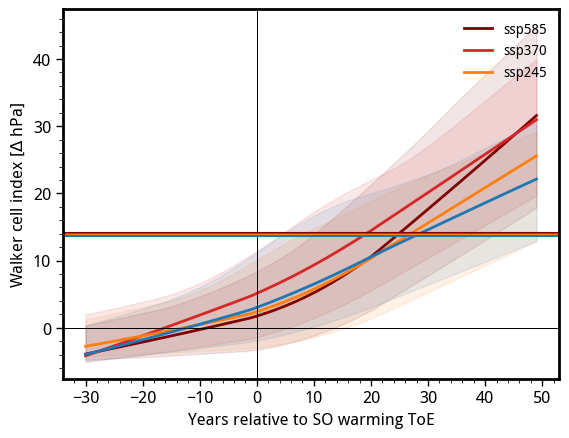

In [ ]:
plot_temporal_causality(temporal_causality5, color='maroon', label='ssp585')
plot_temporal_causality(temporal_causality3, color='tab:red', label='ssp370')
plot_temporal_causality(temporal_causality2, color='tab:orange', label='ssp245')
plot_temporal_causality(temporal_causality1, color='tab:blue')
# plot_temporal_causality(temporal_causality1_ext, color='tab:blue', ls='-', label='ssp126_ext')
# plot_temporal_causality(temporal_causality5o, color='tab:green', label='ssp534_over')
plt.legend(frameon=False, fontsize=10)
plt.minorticks_on()

plt.axhline(0.2*((psl5.wc_index - loess3d(psl5.wc_index, dim='time', period=30)).std('time')).median('model'), color='maroon')
plt.axhline(0.2*((psl3.wc_index - loess3d(psl3.wc_index, dim='time', period=30)).std('time')).median('model'), color='tab:red')
plt.axhline(0.2*((psl2.wc_index - loess3d(psl2.wc_index, dim='time', period=30)).std('time')).median('model'), color='tab:orange')
plt.axhline(0.2*((psl1.wc_index - loess3d(psl1.wc_index, dim='time', period=30)).std('time')).median('model'), color='tab:blue')
# plt.axhline(0.2*((psl5o_ext.wc_index - loess3d(psl5o_ext.wc_index, dim='time', period=30)).std('time')).median('model'), color='tab:green')

plt.ylabel('Walker cell index [$\Delta$ hPa]')
plt.xlabel('Years relative to SO warming ToE')
# sns.despine(offset=5, trim=True)

In [ ]:
toe5_psl = find_signal_exceeds_noise3d(psl5.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
toe3_psl = find_signal_exceeds_noise3d(psl3.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
toe2_psl = find_signal_exceeds_noise3d(psl2.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
toe1_psl = find_signal_exceeds_noise3d(psl1.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
# toe1_ext_psl = find_signal_exceeds_noise3d(psl1_ext.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
toe5o_psl = find_signal_exceeds_noise3d(psl5o.dropna('model').wc_index.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=False)
# toe1 = out1.time.dt.year[find_signal_exceeds_noise3d(signal1, noise1, dim='time', invert=False)]

NameError: name 'psl5o' is not defined

In [ ]:
toe5_sst_grad = find_signal_exceeds_noise3d(sst_grad5.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
toe3_sst_grad = find_signal_exceeds_noise3d(sst_grad3.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
toe2_sst_grad = find_signal_exceeds_noise3d(sst_grad2.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
toe1_sst_grad = find_signal_exceeds_noise3d(sst_grad1.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
# toe1_ext_sst_grad = find_signal_exceeds_noise3d(sst_grad1_ext.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
# toe5o_sst_grad = find_signal_exceeds_noise3d(sst_grad5o.isel(time = slice(1,-1)), dim='time', weight=0.199, invert=True)
# toe1 = out1.time.dt.year[find_signal_exceeds_noise3d(signal1, noise1, dim='time', invert=False)]

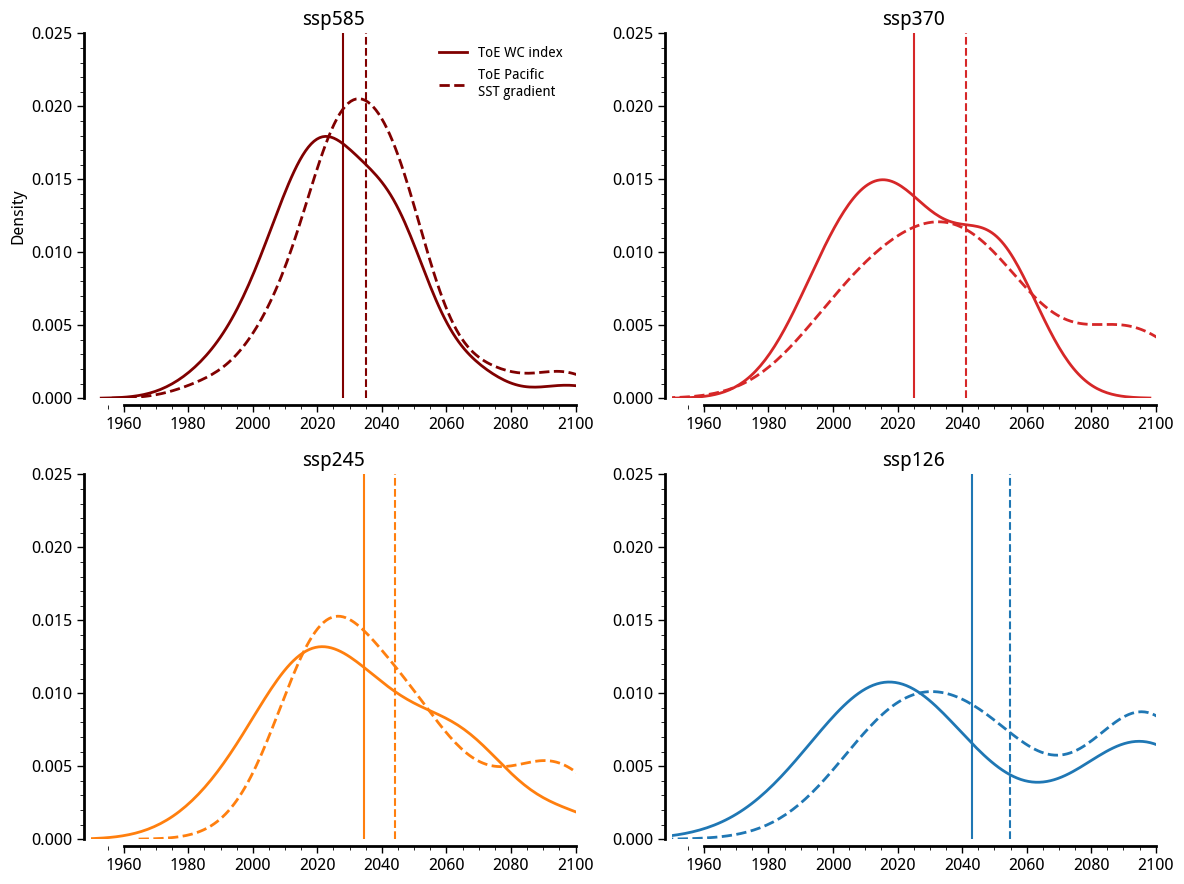

In [ ]:
plt.figure(figsize=(12,9))

plt.subplot(221)
sns.kdeplot(toe5_psl, lw=2.0, color='maroon', label='ToE WC index')
sns.kdeplot(toe5_sst_grad, lw=2.0, color='maroon', ls='--', label='ToE Pacific \nSST gradient')
plt.legend(frameon=False, fontsize=10)
plt.axvline(toe5_psl.mean(), color='maroon')
plt.axvline(toe5_sst_grad.mean(), color='maroon', ls='--')
plt.title('ssp585')
plt.xlim(1950, 2100)
plt.ylim(0, 0.025)
plt.minorticks_on()
sns.despine(offset=5, trim=True)
# plt.ylabel('')
plt.xlabel('')

plt.subplot(222)
sns.kdeplot(toe3_psl, lw=2.0, color='tab:red')
sns.kdeplot(toe3_sst_grad, lw=2.0, color='tab:red', ls='--')
plt.axvline(toe3_psl.mean(), color='tab:red')
plt.axvline(toe3_sst_grad.mean(), color='tab:red', ls='--')
plt.title('ssp370')
plt.ylabel('')
plt.xlabel('')
plt.xlim(1950, 2100)
plt.ylim(0, 0.025)
sns.despine(offset=5, trim=True)
plt.minorticks_on()

plt.subplot(223)
sns.kdeplot(toe2_psl, lw=2.0, color='tab:orange')
sns.kdeplot(toe2_sst_grad, lw=2.0, color='tab:orange', ls='--')
plt.axvline(toe2_psl.mean(), color='tab:orange')
plt.axvline(toe2_sst_grad.mean(), color='tab:orange', ls='--')
plt.title('ssp245')
plt.xlim(1950, 2100)
plt.ylim(0, 0.025)
plt.minorticks_on()
sns.despine(offset=5, trim=True)
plt.ylabel('')
plt.xlabel('')

plt.subplot(224)
sns.kdeplot(toe1_psl, lw=2.0, color='tab:blue')
sns.kdeplot(toe1_sst_grad, lw=2.0, color='tab:blue', ls='--')
plt.axvline(toe1_psl.mean(), color='tab:blue')
plt.axvline(toe1_sst_grad.mean(), color='tab:blue', ls='--')
plt.title('ssp126')
plt.xlim(1950, 2100)
plt.ylim(0, 0.025)
plt.minorticks_on()
sns.despine(offset=5, trim=True)
plt.ylabel('')
plt.xlabel('')

# plt.subplot(325)
# sns.kdeplot(toe5o_psl, lw=2.0, color='tab:green')
# sns.kdeplot(toe5o_sst_grad, lw=2.0, color='tab:green', ls='--')
# plt.axvline(toe5o_psl.mean(), color='tab:green')
# plt.axvline(toe5o_sst_grad.mean(), color='tab:green', ls='--')
# plt.title('ssp534-over')
# plt.xlim(1950, 2100)
# plt.ylim(0, 0.025)
# plt.minorticks_on()
# sns.despine(offset=5, trim=True)
# plt.ylabel('')
# plt.xlabel('')

# plt.subplot(326)
# sns.kdeplot(toe5o_psl, lw=2.0, color='tab:green')
# sns.kdeplot(toe5o_sst_grad, lw=2.0, color='tab:green', ls='--')
# plt.axvline(toe5o_psl.mean(), color='tab:green')
# plt.axvline(toe5o_sst_grad.mean(), color='tab:green', ls='--')
# plt.title('ssp534-over')
# plt.xlim(1950, 2100)
# plt.ylim(0, 0.025)
# plt.minorticks_on()
# sns.despine(offset=5, trim=True)
# plt.ylabel('')
# plt.xlabel('')

plt.tight_layout()

In [ ]:
temporal_causality5 = get_temporal_causality(toe5_psl.where(psl5.model.isin(sst_grad5.model), drop=True), loess3d(sst_grad5.where(psl5.model.isin(sst_grad5.model), drop=True), dim='time', period=30))
temporal_causality3 = get_temporal_causality(toe3_psl.where(psl3.model.isin(sst_grad3.model), drop=True), loess3d(sst_grad3.where(psl3.model.isin(sst_grad3.model), drop=True), dim='time', period=30))
temporal_causality2 = get_temporal_causality(toe2_psl.where(psl2.model.isin(sst_grad2.model), drop=True), loess3d(sst_grad2.where(psl2.model.isin(sst_grad2.model), drop=True), dim='time', period=30))
temporal_causality1 = get_temporal_causality(toe1_psl.where(psl1.model.isin(sst_grad1.model), drop=True), loess3d(sst_grad1.where(psl1.model.isin(sst_grad1.model), drop=True), dim='time', period=30))
# temporal_causality5o = get_temporal_causality(toe5o_psl.where(psl5o.model.isin(sst_grad5o.model), drop=True), loess3d(sst_grad5o.where(psl5o.model.isin(sst_grad5o.model), drop=True), dim='time', period=30))

In [ ]:
# temporal_causality1 = get_temporal_causality(toe1_psl.where(psl1.model.isin(sst_grad1.model), drop=True), loess3d(sst_grad1.where(psl1.model.isin(sst_grad1.model), drop=True), dim='time', period=30))

Text(0.5, 0, 'Years relative to ToE in WC index (30-year rolling WC index > 0)')

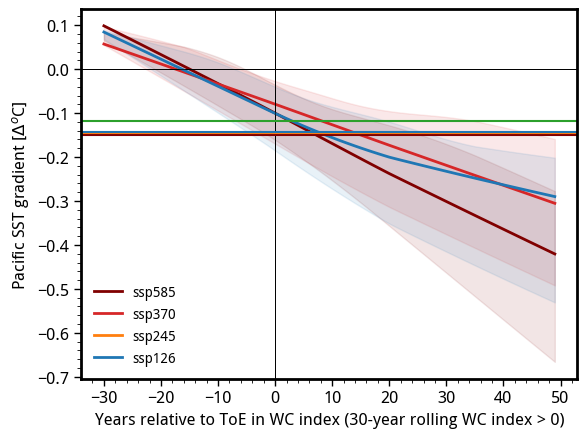

: 

In [ ]:
plot_temporal_causality(temporal_causality5, color='maroon', label='ssp585')
plot_temporal_causality(temporal_causality3, color='tab:red', label='ssp370')
temporal_causality2[temporal_causality2 > 100] = np.nan
plot_temporal_causality(temporal_causality2, color='tab:orange', label='ssp245')
plot_temporal_causality(temporal_causality1, color='tab:blue', label='ssp126')
# plot_temporal_causality(temporal_causality1_ext, color='tab:blue', ls='-', label='ssp126_ext')
# plot_temporal_causality(temporal_causality5o, color='tab:green', label='ssp534_over')
plt.legend(frameon=False, fontsize=10)
plt.minorticks_on()

plt.axhline(-0.2*((sst_grad5 - loess3d(sst_grad5, dim='time', period=30)).std('time')).mean('model'), color='maroon')
plt.axhline(-0.2*((sst_grad3 - loess3d(sst_grad3, dim='time', period=30)).std('time')).mean('model'), color='tab:red')
plt.axhline(-0.2*((sst_grad2 - loess3d(sst_grad2, dim='time', period=30)).std('time')).mean('model'), color='tab:orange')
plt.axhline(-0.2*((sst_grad1 - loess3d(sst_grad1, dim='time', period=30)).std('time')).mean('model'), color='tab:blue')
plt.axhline(-0.2*((sst_grad5o_ext - loess3d(sst_grad5o_ext, dim='time', period=30)).std('time')).mean('model'), color='tab:green')

plt.ylabel('Pacific SST gradient [$\Delta ^{o}$C]')
plt.xlabel('Years relative to ToE in WC index (30-year rolling WC index > 0)')

In [ ]:
import json
f = open('data/cmip56_forcing_feedback_ecs.json')
data = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'data/cmip56_forcing_feedback_ecs.json'

In [ ]:
data.keys()

In [ ]:
data['CMIP6']

In [ ]:
ecs = []
models = []
for m in ts5.model.to_numpy():
    try:
        ecs.append(data['CMIP6'][str(m)]['r1i1p1f1']['ECS'])
        models.append(m)
    except:
        ecs.append(np.nan)
        models.append(m)

ecs_grad = pd.DataFrame(data=dict(model = models, ecs=ecs, so_warming = so_warming5))
ecs_grad = ecs_grad.set_index('model')


In [ ]:
ecs_grad

In [ ]:
sns.regplot(ecs_grad, x='ecs', y='so_warming')
stats.spearmanr(ecs_grad.dropna()['ecs'], ecs_grad.dropna()['so_warming'])

In [ ]:
plt.boxplot([ecs_grad['ecs'].to_xarray().where(test1 > test1.quantile(0.75, 'model')).dropna('model'),
             ecs_grad['ecs'].to_xarray().where(test1 < test1.quantile(0.25, 'model')).dropna('model')], whis=[5,95])